# Text Vectorization: TF-IDF, One-Hot Encoding, & Reduksi Dimensi (PCA vs SVD)

Tahap ini mengubah teks bersih menjadi representasi numerik menggunakan **TF-IDF**, meng-encode label (**One-Hot Encoding**), lalu membandingkan dua teknik reduksi dimensi yang umum dipakai untuk data teks: **PCA (Principal Component Analysis)** dan **Truncated SVD (Singular Value Decomposition)**.

**Alur:**

```
Teks bersih (200 dokumen)
        |
   TF-IDF Vectorization  -> matriks (200 x jumlah kata unik)
        |
   One-Hot Encoding label
        |
   Simpan dataset TF-IDF penuh
        |
   Reduksi Dimensi: PCA  VS  Truncated SVD (LSA)
        |
   Bandingkan hasil keduanya
        |
   Simpan kedua dataset hasil reduksi
```

## 1. Load Dataset Hasil Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

df = pd.read_excel("../data/dataset_berita_200_bersih.xlsx")
print("Ukuran dataset:", df.shape)
df[["id", "label", "teks_bersih"]].head(3)

Ukuran dataset: (200, 4)


,id,label,teks_bersih
0,1,sport,chef de mission cdm indonesia todotua pasaribu...
1,2,sport,banjir besar melanda nagoya jepang menjelang a...
2,3,sport,ketua umum komite olimpiade indonesia koi raja...


## 2. TF-IDF Vectorization

```{admonition} Apa itu TF-IDF?
:class: note

**TF-IDF (Term Frequency - Inverse Document Frequency)** memberi bobot pada tiap kata berdasarkan dua hal:
- **TF** - seberapa sering kata muncul dalam satu dokumen.
- **IDF** - seberapa "jarang" kata itu muncul di seluruh korpus. Kata yang muncul di hampir semua dokumen (misal "yang", "dan") mendapat bobot rendah, sedangkan kata yang khas untuk topik tertentu mendapat bobot tinggi.
```

Parameter `min_df=3` diterapkan agar kata yang hanya muncul di 1-2 dokumen (seringkali nama orang/tempat yang disebut sesekali) tidak ikut menjadi fitur, sehingga vocabulary lebih fokus pada kata yang representatif.

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=3)
tfidf_matrix = vectorizer.fit_transform(df["teks_bersih"])

print("Ukuran matriks TF-IDF:", tfidf_matrix.shape)
print("Jumlah kata unik (vocabulary):", len(vectorizer.get_feature_names_out()))
print("Tipe data matriks:", type(tfidf_matrix), "(sparse - sebagian besar nilainya 0)")

Ukuran matriks TF-IDF: (200, 2556)
Jumlah kata unik (vocabulary): 2556
Tipe data matriks: <class 'scipy.sparse._csr.csr_matrix'> (sparse - sebagian besar nilainya 0)


### Susun sebagai DataFrame: Baris = Dokumen (Korpus), Kolom = Kata Unik (Indeks), Nilai = Bobot TF-IDF

In [3]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)
tfidf_df.insert(0, "doc_id", df["id"].values)

print("Ukuran DataFrame TF-IDF (sebelum label):", tfidf_df.shape)
sampel = tfidf_df.iloc[:10, 1:11]
sampel.style.background_gradient(cmap="Blues", axis=None).format("{:.3f}")

Ukuran DataFrame TF-IDF (sebelum label): (200, 2557)


,10k,5k,abdul,absen,abu,acara,acd,aceh,acosta,ada
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.081
1,0.000,0.000,0.000,0.000,0.000,0.040,0.000,0.000,0.000,0.046
2,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.072
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.029
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.023
6,0.000,0.000,0.136,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.032,0.000,0.000,0.000,0.018
8,0.000,0.000,0.000,0.000,0.000,0.035,0.000,0.000,0.000,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


### Kata Paling Khas per Kategori

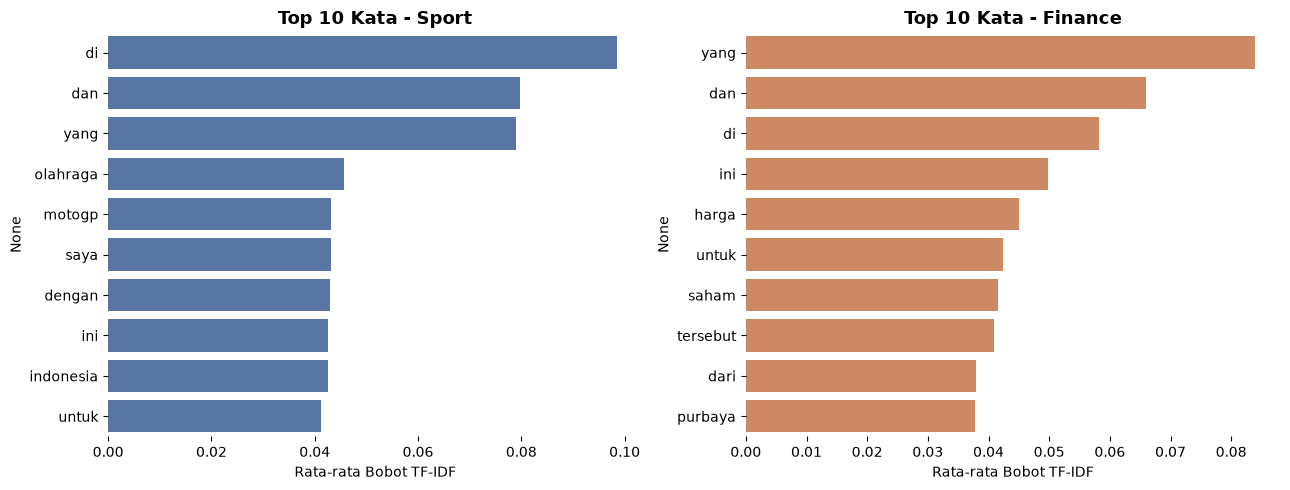

In [4]:
tfidf_dengan_label = tfidf_df.drop(columns=["doc_id"]).copy()
tfidf_dengan_label["label"] = df["label"].values

top_n = 10
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, kategori, warna in zip(axes, ["sport", "finance"], ["#4C72B0", "#DD8452"]):
    rata_rata = tfidf_dengan_label[tfidf_dengan_label["label"] == kategori].drop(columns=["label"]).mean()
    top_kata = rata_rata.sort_values(ascending=False).head(top_n)
    sns.barplot(x=top_kata.values, y=top_kata.index, ax=ax, color=warna)
    ax.set_title(f"Top {top_n} Kata - {kategori.capitalize()}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Rata-rata Bobot TF-IDF")
    sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

### Vocabulary Eksklusif per Kategori

In [5]:
kata_sport = set(tfidf_dengan_label[tfidf_dengan_label["label"] == "sport"].drop(columns=["label"]).columns[
    (tfidf_dengan_label[tfidf_dengan_label["label"] == "sport"].drop(columns=["label"]).sum() > 0)
])
kata_finance = set(tfidf_dengan_label[tfidf_dengan_label["label"] == "finance"].drop(columns=["label"]).columns[
    (tfidf_dengan_label[tfidf_dengan_label["label"] == "finance"].drop(columns=["label"]).sum() > 0)
])

hanya_sport = kata_sport - kata_finance
hanya_finance = kata_finance - kata_sport
bersama = kata_sport & kata_finance

vocab_summary = pd.DataFrame({
    "kategori": ["Hanya di Sport", "Hanya di Finance", "Muncul di Keduanya"],
    "jumlah_kata": [len(hanya_sport), len(hanya_finance), len(bersama)],
})
vocab_summary

,kategori,jumlah_kata
0,Hanya di Sport,530
1,Hanya di Finance,501
2,Muncul di Keduanya,1525


## 3. One-Hot Encoding Label

In [6]:
label_encoded = pd.get_dummies(df["label"], prefix="label").astype(int)
print(label_encoded.head())
print("\nKolom hasil one-hot encoding:", list(label_encoded.columns))

   label_finance  label_sport
0              0            1
1              0            1
2              0            1
3              0            1
4              0            1

Kolom hasil one-hot encoding: ['label_finance', 'label_sport']


In [7]:
dataset_tfidf_final = pd.concat([tfidf_df, label_encoded, df["label"].rename("label_asli")], axis=1)
dataset_tfidf_final.to_excel("../data/dataset_tfidf.xlsx", index=False)
print("Ukuran dataset TF-IDF final:", dataset_tfidf_final.shape)
print("Dataset TF-IDF disimpan ke data/dataset_tfidf.xlsx")

Ukuran dataset TF-IDF final: (200, 2560)
Dataset TF-IDF disimpan ke data/dataset_tfidf.xlsx


## 4. Reduksi Dimensi: PCA vs Truncated SVD

```{admonition} PCA vs SVD - Apa Bedanya?
:class: tip

Keduanya sama-sama teknik reduksi dimensi, tapi caranya berbeda:

- **PCA (Principal Component Analysis)** mula-mula men-*center*-kan data (mengurangi tiap kolom dengan rata-ratanya), lalu mencari arah dengan variasi terbesar. Proses centering ini membuat matriks yang tadinya *sparse* (banyak nilai nol) menjadi *dense* (penuh angka), sehingga untuk data TF-IDF berukuran besar, PCA menjadi kurang efisien.
- **Truncated SVD (Singular Value Decomposition)** bekerja langsung pada matriks asli **tanpa proses centering**, sehingga bisa langsung memproses matriks sparse tanpa perlu diubah ke bentuk dense terlebih dahulu. SVD lebih efisien secara komputasi untuk data teks berdimensi besar seperti TF-IDF. Ketika diterapkan pada matriks TF-IDF, teknik ini dikenal juga sebagai **LSA (Latent Semantic Analysis)**.
```

Kita terapkan keduanya dan bandingkan hasilnya secara langsung.

### 4.1 Menentukan Jumlah Komponen (Target 80% Variance) - untuk PCA

In [8]:
from sklearn.decomposition import PCA

maks_komponen = min(199, tfidf_matrix.shape[0] - 1, tfidf_matrix.shape[1])

pca_cek = PCA(n_components=maks_komponen)
pca_cek.fit(tfidf_matrix.toarray())
variance_kumulatif_pca = np.cumsum(pca_cek.explained_variance_ratio_)

n_komponen_pca = int(np.argmax(variance_kumulatif_pca >= 0.80) + 1)
print(f"[PCA] Jumlah komponen untuk 80% variance: {n_komponen_pca}")

[PCA] Jumlah komponen untuk 80% variance: 104


### 4.2 Menentukan Jumlah Komponen (Target 80% Variance) - untuk Truncated SVD

In [9]:
from sklearn.decomposition import TruncatedSVD

svd_cek = TruncatedSVD(n_components=maks_komponen, random_state=42)
svd_cek.fit(tfidf_matrix)  # langsung pada matriks sparse, tanpa .toarray()
variance_kumulatif_svd = np.cumsum(svd_cek.explained_variance_ratio_)

n_komponen_svd = int(np.argmax(variance_kumulatif_svd >= 0.80) + 1)
print(f"[SVD] Jumlah komponen untuk 80% variance: {n_komponen_svd}")

[SVD] Jumlah komponen untuk 80% variance: 105


### 4.3 Bandingkan Kurva Explained Variance

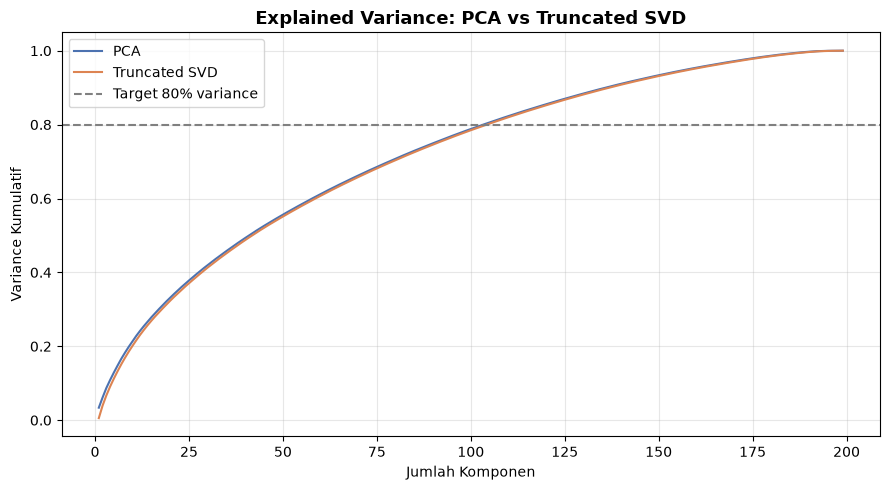

In [10]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(variance_kumulatif_pca) + 1), variance_kumulatif_pca, label="PCA", color="#4C72B0")
plt.plot(range(1, len(variance_kumulatif_svd) + 1), variance_kumulatif_svd, label="Truncated SVD", color="#DD8452")
plt.axhline(y=0.80, color="gray", linestyle="--", label="Target 80% variance")
plt.xlabel("Jumlah Komponen")
plt.ylabel("Variance Kumulatif")
plt.title("Explained Variance: PCA vs Truncated SVD", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Terapkan Kedua Teknik & Ukur Waktu Komputasi

In [11]:
# --- PCA ---
mulai = time.time()
pca = PCA(n_components=n_komponen_pca, random_state=42)
tfidf_pca = pca.fit_transform(tfidf_matrix.toarray())  # perlu .toarray() -> lebih berat
waktu_pca = time.time() - mulai

# --- Truncated SVD ---
mulai = time.time()
svd = TruncatedSVD(n_components=n_komponen_svd, random_state=42)
tfidf_svd = svd.fit_transform(tfidf_matrix)  # langsung pada sparse matrix -> lebih ringan
waktu_svd = time.time() - mulai

print(f"PCA : {tfidf_pca.shape}, variance dipertahankan {pca.explained_variance_ratio_.sum():.4f}, waktu {waktu_pca:.3f} detik")
print(f"SVD : {tfidf_svd.shape}, variance dipertahankan {svd.explained_variance_ratio_.sum():.4f}, waktu {waktu_svd:.3f} detik")

PCA : (200, 104), variance dipertahankan 0.7985, waktu 0.163 detik
SVD : (200, 105), variance dipertahankan 0.8003, waktu 0.456 detik


### 4.5 Visualisasi 2D: PCA vs SVD Berdampingan

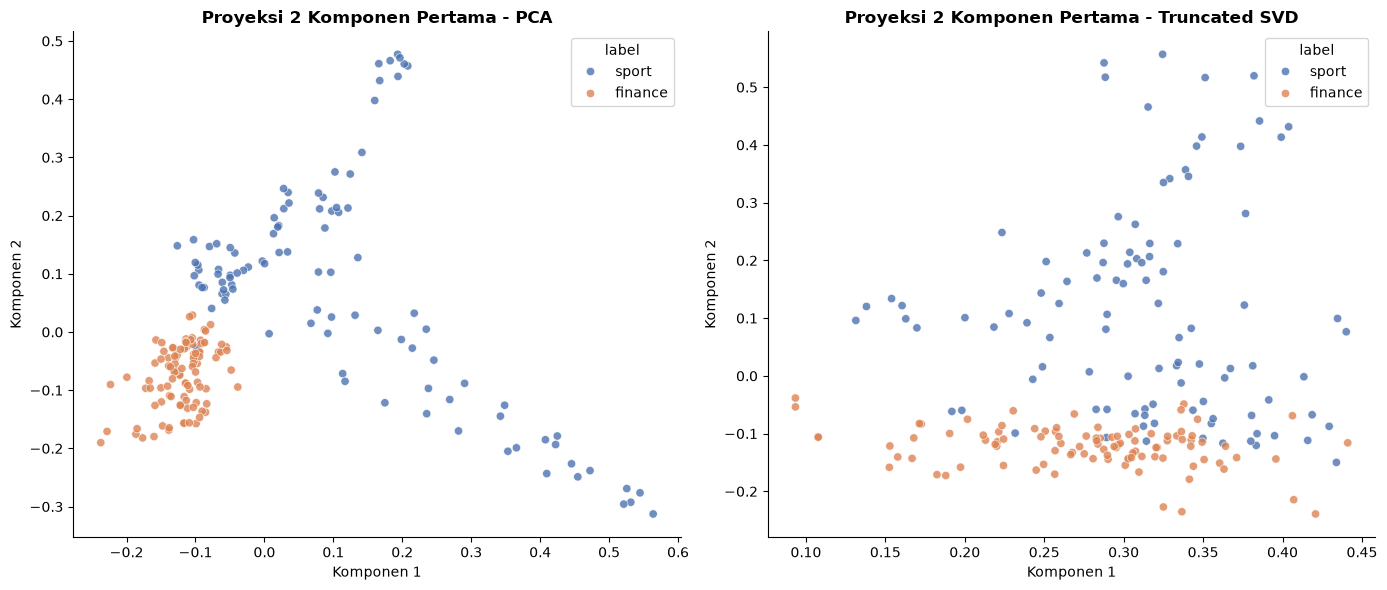

Variance yang tertangkap oleh 2 komponen pertama saja:
  PCA : 0.0614 (6.1%)
  SVD : 0.0394 (3.9%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, hasil, judul in zip(axes, [tfidf_pca, tfidf_svd], ["PCA", "Truncated SVD"]):
    sns.scatterplot(
        x=hasil[:, 0], y=hasil[:, 1],
        hue=df["label"], palette={"sport": "#4C72B0", "finance": "#DD8452"},
        ax=ax, alpha=0.8
    )
    ax.set_xlabel("Komponen 1")
    ax.set_ylabel("Komponen 2")
    ax.set_title(f"Proyeksi 2 Komponen Pertama - {judul}", fontsize=12, fontweight="bold")
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

print(f"Variance yang tertangkap oleh 2 komponen pertama saja:")
print(f"  PCA : {pca_cek.explained_variance_ratio_[:2].sum():.4f} ({pca_cek.explained_variance_ratio_[:2].sum()*100:.1f}%)")
print(f"  SVD : {svd_cek.explained_variance_ratio_[:2].sum():.4f} ({svd_cek.explained_variance_ratio_[:2].sum()*100:.1f}%)")

**Interpretasi:** Nilai variance yang tertangkap oleh 2 komponen pertama biasanya terlihat kecil karena data TF-IDF memiliki ribuan dimensi - ini wajar. Menariknya, pada dataset skala kecil ini (200 dokumen), Truncated SVD justru sedikit lebih lambat dibanding PCA dalam waktu komputasi mentah - keunggulan efisiensi SVD terhadap data sparse baru signifikan pada dataset berskala jauh lebih besar. Secara visual, PCA menghasilkan pemisahan sport-finance yang tampak lebih rapi pada 2 komponen pertama dibanding SVD pada dataset ini, meski keduanya menangkap proporsi variance yang serupa - menunjukkan bahwa "variance terbesar" tidak selalu berarti "pemisahan kelas terbaik". Baik dataset TF-IDF, PCA, maupun SVD tetap disiapkan sebagai alternatif input untuk tahap Modeling, agar performa klasifikasi dari ketiganya bisa dibandingkan secara empiris.

### 4.6 Simpan Kedua Dataset Hasil Reduksi

In [13]:
kolom_pca = [f"pc_{i+1}" for i in range(n_komponen_pca)]
pca_df = pd.DataFrame(tfidf_pca, columns=kolom_pca)
pca_df.insert(0, "doc_id", df["id"].values)
dataset_pca_final = pd.concat([pca_df, label_encoded, df["label"].rename("label_asli")], axis=1)
dataset_pca_final.to_excel("../data/dataset_pca.xlsx", index=False)

kolom_svd = [f"svd_{i+1}" for i in range(n_komponen_svd)]
svd_df = pd.DataFrame(tfidf_svd, columns=kolom_svd)
svd_df.insert(0, "doc_id", df["id"].values)
dataset_svd_final = pd.concat([svd_df, label_encoded, df["label"].rename("label_asli")], axis=1)
dataset_svd_final.to_excel("../data/dataset_svd.xlsx", index=False)

print("Dataset PCA disimpan ke data/dataset_pca.xlsx :", dataset_pca_final.shape)
print("Dataset SVD disimpan ke data/dataset_svd.xlsx :", dataset_svd_final.shape)

Dataset PCA disimpan ke data/dataset_pca.xlsx : (200, 108)
Dataset SVD disimpan ke data/dataset_svd.xlsx : (200, 109)


## 5. Ringkasan Perbandingan

In [14]:
ringkasan = pd.DataFrame({
    "Metode": ["TF-IDF (sebelum reduksi)", "PCA", "Truncated SVD"],
    "Jumlah Kolom": [tfidf_matrix.shape[1], n_komponen_pca, n_komponen_svd],
    "Variance Dipertahankan": ["100% (data asli)", f"{pca.explained_variance_ratio_.sum():.1%}", f"{svd.explained_variance_ratio_.sum():.1%}"],
    "Perlu Data Dense?": ["-", "Ya (.toarray())", "Tidak (langsung sparse)"],
    "Waktu Komputasi (detik)": ["-", f"{waktu_pca:.3f}", f"{waktu_svd:.3f}"],
})
ringkasan

,Metode,Jumlah Kolom,Variance Dipertahankan,Perlu Data Dense?,Waktu Komputasi (detik)
0,TF-IDF (sebelum reduksi),2556,100% (data asli),-,-
1,PCA,104,79.8%,Ya (.toarray()),0.163
2,Truncated SVD,105,80.0%,Tidak (langsung sparse),0.456


- **Dataset TF-IDF** (`data/dataset_tfidf.xlsx`): representasi penuh, 200 dokumen x seluruh kata unik.
- **Dataset PCA** (`data/dataset_pca.xlsx`) dan **Dataset SVD** (`data/dataset_svd.xlsx`): dua alternatif hasil reduksi dimensi, keduanya mempertahankan ~80% variance dari data asli namun dengan pendekatan komputasi yang berbeda.
- **Truncated SVD** lebih sesuai secara teknis untuk data TF-IDF karena bekerja langsung pada matriks sparse tanpa perlu proses centering, sehingga lebih efisien untuk dataset dengan jumlah fitur yang sangat besar.
- Ketiga dataset (TF-IDF, PCA, SVD) disiapkan sebagai alternatif input untuk tahap **Modeling** - perbandingan performa klasifikasi menggunakan ketiganya dapat menjadi bagian menarik dari analisis pada tahap berikutnya.